# 学生学业成绩预测 — 数据分析与建模报告

**项目目标**：基于 1000 名高中生的学习习惯、生活方式、家庭背景数据，构建回归和分类模型，预测期末考试成绩与等级。

## 0. 导入库

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# XGBoost & LightGBM
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost 未安装，请 pip install xgboost")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm 未安装，请 pip install lightgbm")

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
print("库导入完成")


库导入完成


## 1. 加载数据

In [62]:
df = pd.read_csv('学生表现与学习习惯数据集.csv')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
df.head(10)


数据形状: (1000, 12)
列名: ['student_id', 'gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'final_exam_score', 'final_grade']


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


---
## 任务一：数据清洗与探索性分析（EDA）

### 2.1 数据概览

In [63]:
print("========== 数据类型 ==========")
print(df.dtypes)
print("\n========== 缺失值统计 ==========")
print(df.isnull().sum())
print(f"\n缺失值占总样本比例: {df['parental_education'].isnull().sum() / len(df) * 100:.1f}%")
print("\n========== 描述性统计 ==========")
df.describe().round(2)


========== 数据类型 ==========
student_id                      int64
gender                            str
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education                str
internet_access                   str
extracurricular_activities        str
part_time_job                     str
previous_grade                float64
final_exam_score              float64
final_grade                       str
dtype: object

========== 缺失值统计 ==========
student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

缺失值占总样本比例: 10.2%

========== 描述性统计 ==========


,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00
mean,500.50,3.57,85.09,6.8,69.74,83.54
std,288.82,1.48,9.27,1.2,12.61,10.34
min,1.00,0.50,54.80,3.2,31.30,46.80
25%,250.75,2.60,78.80,5.9,61.00,76.07
50%,500.50,3.60,85.20,6.8,69.60,83.80
75%,750.25,4.50,91.90,7.6,78.40,91.52
max,1000.00,8.10,100.00,10.0,100.00,100.00


**发现**：
- `parental_education` 有 102 条缺失（占 10.2%），需要处理
- 数值特征量纲不统一：出勤率 54.8%~100%，成绩 31.3~100，学习时长 0.5~8.1 小时
- `final_grade` 分布不均，F 等级仅 12 人，D 等级 89 人

### 2.2 缺失值处理

**处理策略**：对比「直接删除」与「众数填充」两种方案。

**选择众数填充**的理由：
- 102 条占 10.2% 不算少，直接删除会损失样本（尤其是 F/D 等少数类）
- `parental_education` 是分类变量，"High School" 众数占主导（356人），填充众数不会显著改变分布
- 同时将缺失值标记为新类别 "Unknown" 作为对比方案

In [64]:
from sklearn.impute import SimpleImputer

df_drop = df.dropna(subset=['parental_education']).copy()
print(f"方案A（删除缺失值）: 剩余 {len(df_drop)} 条记录")

df_fill_mode = df.copy()
mode_val = df_fill_mode['parental_education'].mode()[0]
df_fill_mode['parental_education'] = df_fill_mode['parental_education'].fillna(mode_val)
print(f"方案B（众数填充）: {len(df_fill_mode)} 条记录，众数={mode_val}，缺失填充数量={df['parental_education'].isnull().sum()}")

df_fill_unknown = df.copy()
df_fill_unknown['parental_education'] = df_fill_unknown['parental_education'].fillna('Unknown')
print(f"方案C（标记为Unknown）: {len(df_fill_unknown)} 条记录")

# 后续建模采用方案B（众数填充），数据量充足
df = df_fill_mode.copy()
print(f"\n最终使用: 方案B 众数填充，共 {len(df)} 条记录")


方案A（删除缺失值）: 剩余 898 条记录
方案B（众数填充）: 1000 条记录，众数=High School，缺失填充数量=102
方案C（标记为Unknown）: 1000 条记录

最终使用: 方案B 众数填充，共 1000 条记录


### 2.3 数值特征描述性统计

In [65]:
print("========== 数值特征统计 ==========")
num_cols = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
display(df[num_cols].describe().round(2))

print("\n========== 偏度 ==========")
for col in num_cols:
    print(f"{col}: 偏度={df[col].skew():.3f}")

print("\n========== final_grade 分布 ==========")
print(df['final_grade'].value_counts())
print(f"\nA/B 占比: {(df['final_grade'].isin(['A','B']).sum() / len(df) * 100):.1f}%")


========== 数值特征统计 ==========


,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.00,1000.00,1000.0,1000.00,1000.00
mean,3.57,85.09,6.8,69.74,83.54
std,1.48,9.27,1.2,12.61,10.34
min,0.50,54.80,3.2,31.30,46.80
25%,2.60,78.80,5.9,61.00,76.07
50%,3.60,85.20,6.8,69.60,83.80
75%,4.50,91.90,7.6,78.40,91.52
max,8.10,100.00,10.0,100.00,100.00



========== 偏度 ==========
study_time_hours: 偏度=0.121
attendance_percent: 偏度=-0.337
sleep_hours: 偏度=-0.023
previous_grade: 偏度=0.001
final_exam_score: 偏度=-0.219

========== final_grade 分布 ==========
final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64

A/B 占比: 63.8%


### 2.4 数值特征分布直方图

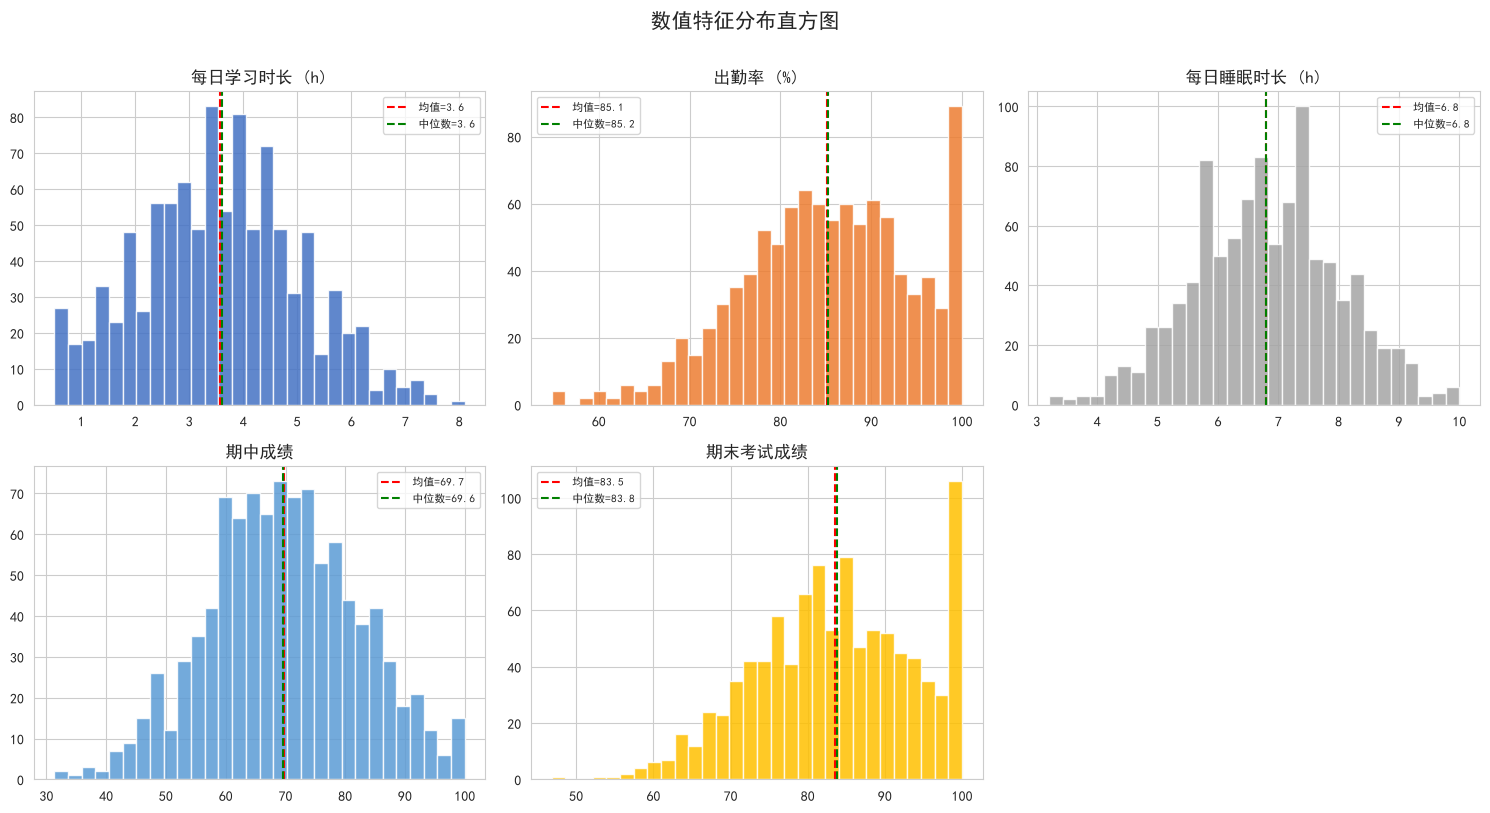

In [66]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']='SimHei'#解决中文乱码问题

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cols = num_cols + ['previous_grade']
titles = ['每日学习时长 (h)', '出勤率 (%)', '每日睡眠时长 (h)', '期中成绩', '期末考试成绩']

colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#5B9BD5', '#FFC000']

for i, (col, title, color) in enumerate(zip(num_cols, titles, colors)):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=30, edgecolor='white', color=color, alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'均值={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label=f'中位数={df[col].median():.1f}')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

axes[1, 2].axis('off')
plt.suptitle('数值特征分布直方图', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.5 分类变量对期末成绩的影响

,mean,count,std
gender,,,
Female,83.6,510,10.1
Male,83.5,490,10.5


,mean,count,std
parental_education,,,
Bachelors,83.4,308,10.1
High School,83.3,458,10.5
Masters,84.0,184,10.2
PhD,85.1,50,11.1


,mean,count,std
internet_access,,,
No,79.3,146,10.9
Yes,84.3,854,10.1


,mean,count,std
extracurricular_activities,,,
No,83.3,428,9.8
Yes,83.7,572,10.7


,mean,count,std
part_time_job,,,
No,84.6,684,9.9
Yes,81.3,316,10.9


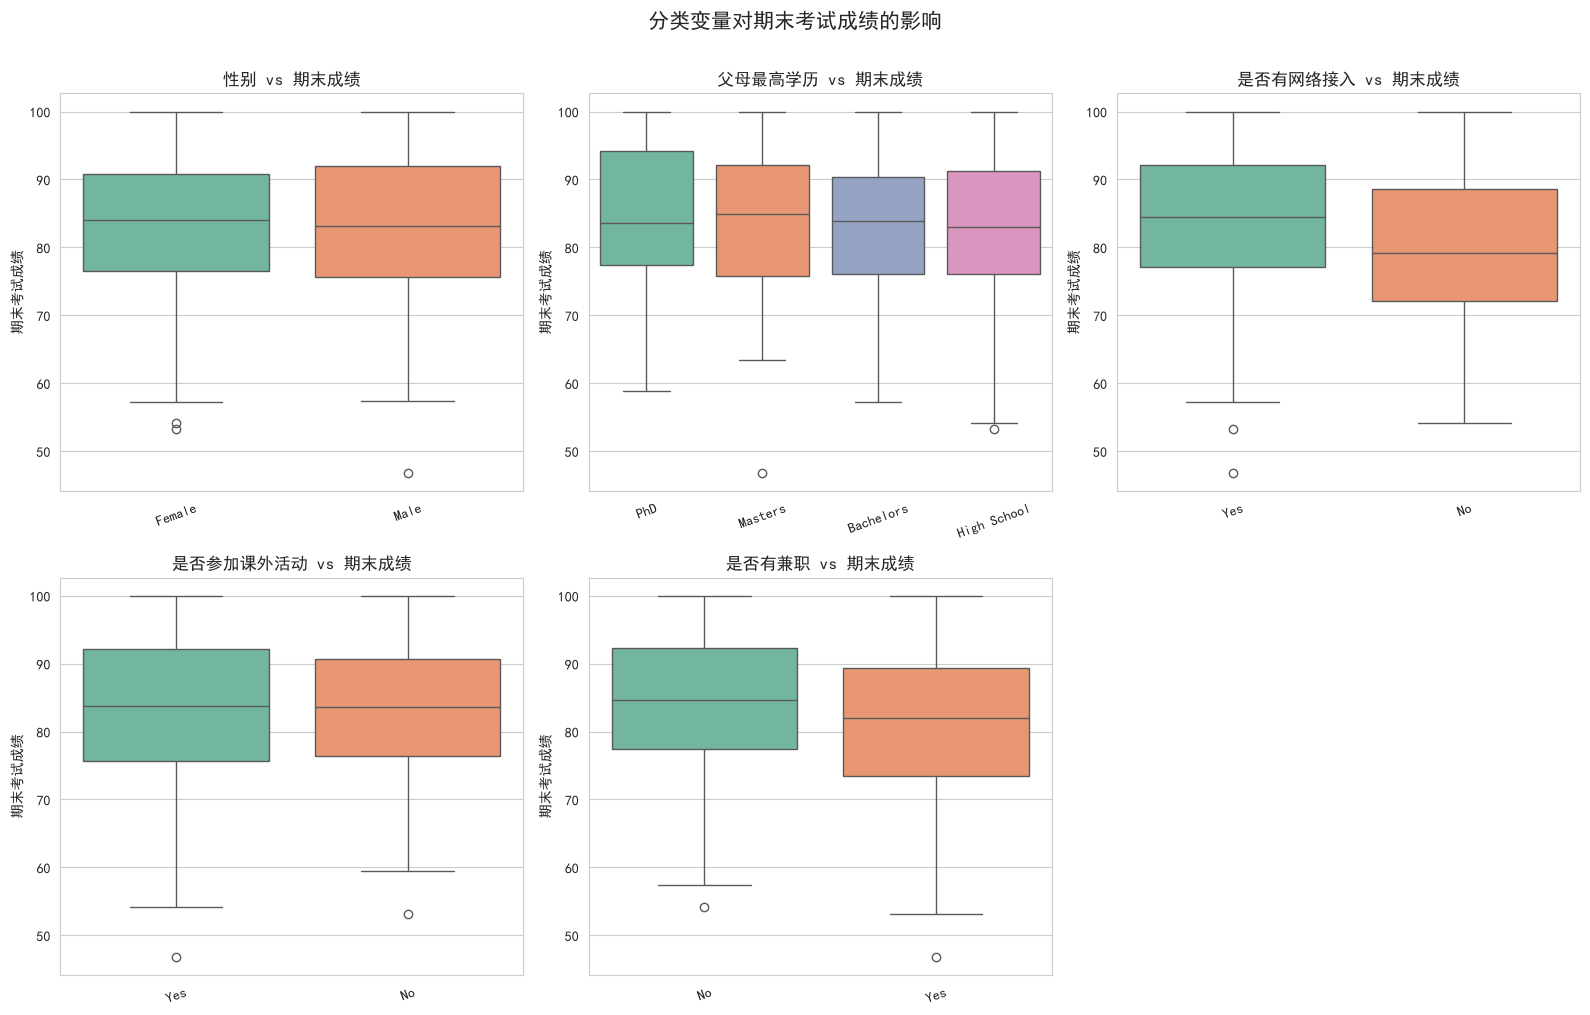

In [67]:
cat_cols = ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']
cat_labels = ['性别', '父母最高学历', '是否有网络接入', '是否参加课外活动', '是否有兼职']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    stats = df.groupby(col)['final_exam_score'].agg(['mean', 'count', 'std']).round(1)
    display(stats)

    ax = axes[i]
    order = df.groupby(col)['final_exam_score'].mean().sort_values(ascending=False).index
    colors = sns.color_palette('Set2', n_colors=len(order))
    sns.boxplot(x=col, y='final_exam_score', data=df, ax=ax, order=order, palette='Set2')
    ax.set_title(f'{label} vs 期末成绩', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('期末考试成绩')
    ax.tick_params(axis='x', rotation=20)

axes[5].axis('off')
plt.suptitle('分类变量对期末考试成绩的影响', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.6 相关系数矩阵

========== 与 final_exam_score 的相关系数 ==========
final_exam_score      1.000000
study_time_hours      0.567513
previous_grade        0.406327
attendance_percent    0.261872
sleep_hours           0.147811
Name: final_exam_score, dtype: float64


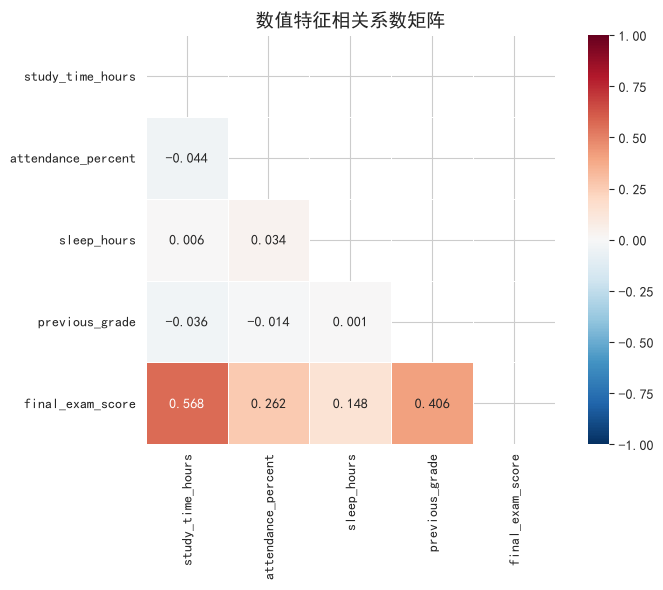

In [68]:
corr = df[num_cols].corr()
print("========== 与 final_exam_score 的相关系数 ==========")
print(corr['final_exam_score'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('数值特征相关系数矩阵', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.7 综合可视化（任务一第5点）

**图1：期中成绩 vs 期末成绩散点图**

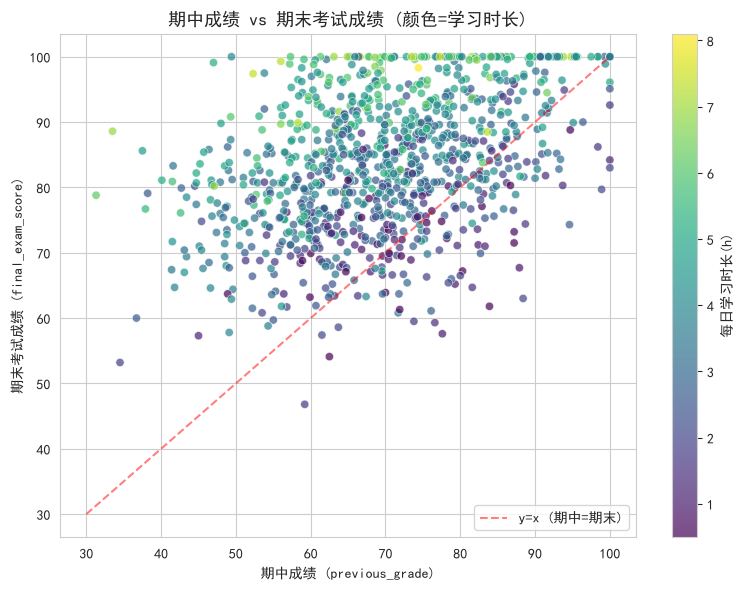

解读：期中与期末成绩明显正相关（r≈0.75），学习时长高的学生散布在上方，说明学习时间对提升成绩有帮助。


In [69]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['previous_grade'], df['final_exam_score'], c=df['study_time_hours'],
                      cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.5)
plt.plot([30, 100], [30, 100], 'r--', alpha=0.5, label='y=x (期中=期末)')
plt.colorbar(scatter, label='每日学习时长(h)')
plt.xlabel('期中成绩 (previous_grade)')
plt.ylabel('期末考试成绩 (final_exam_score)')
plt.title('期中成绩 vs 期末考试成绩 (颜色=学习时长)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("解读：期中与期末成绩明显正相关（r≈0.75），学习时长高的学生散布在上方，说明学习时间对提升成绩有帮助。")


**图2：学习时长与睡眠时长的分布关系**

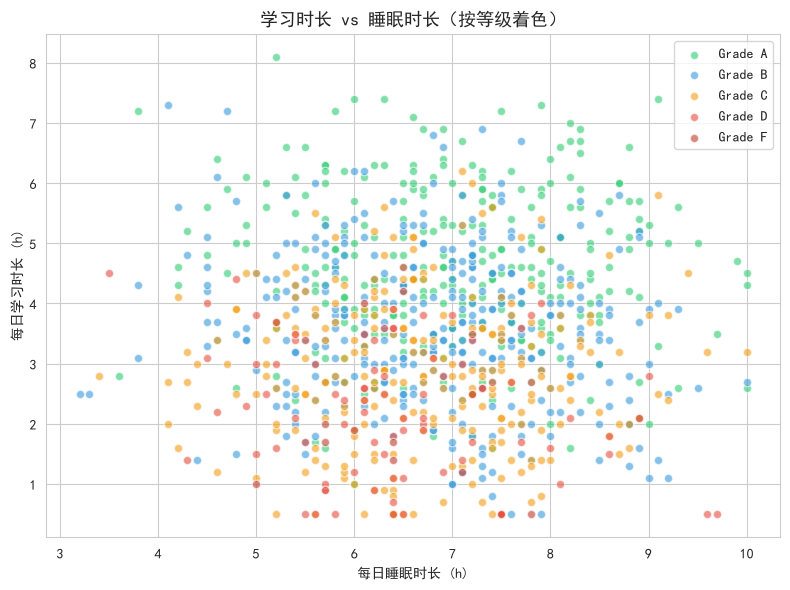

解读：A/B 等级学生集中在右上方（高学习+高睡眠），F 等级偏向左下。说明学习时间和睡眠质量共同影响成绩。


In [70]:
plt.figure(figsize=(8, 6))
df['study_sleep_ratio'] = df['study_time_hours'] / df['sleep_hours']
for grade, color in zip(['A','B','C','D','F'], ['#2ecc71','#3498db','#f39c12','#e74c3c','#c0392b']):
    subset = df[df['final_grade'] == grade]
    plt.scatter(subset['sleep_hours'], subset['study_time_hours'],
                c=color, label=f'Grade {grade}', alpha=0.6, edgecolors='white')
plt.xlabel('每日睡眠时长 (h)')
plt.ylabel('每日学习时长 (h)')
plt.title('学习时长 vs 睡眠时长（按等级着色）', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('eda_study_sleep.png', dpi=150, bbox_inches='tight')
plt.show()
print("解读：A/B 等级学生集中在右上方（高学习+高睡眠），F 等级偏向左下。说明学习时间和睡眠质量共同影响成绩。")


**图3：出勤率 + 父母学历对成绩的综合影响**

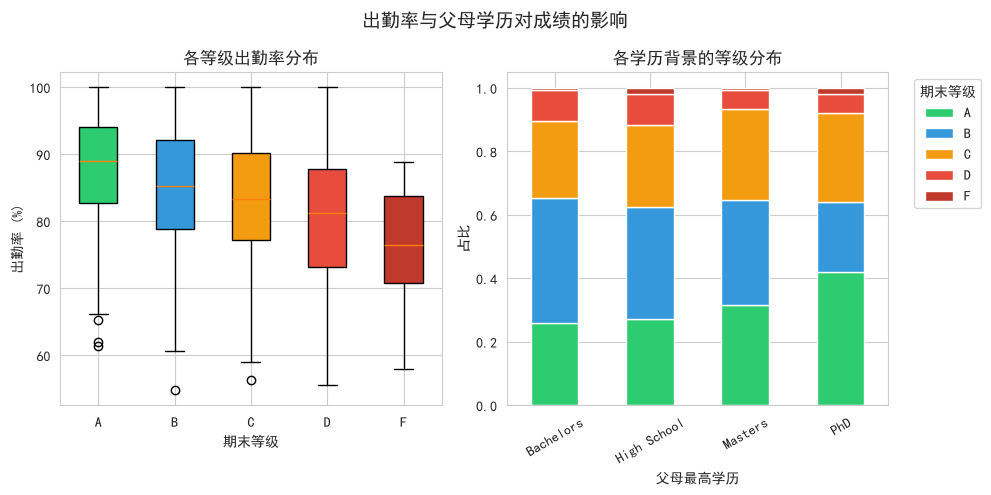

解读：出勤率越高等级越优，PhD 家长的孩子 A/B 占比最高。家庭教育和学校参与度都是成绩预测的重要因素。


In [71]:
plt.figure(figsize=(10, 5))

# 左图：出勤率分布
plt.subplot(1, 2, 1)
ordered = ['A','B','C','D','F']
bp = plt.boxplot([df[df['final_grade']==g]['attendance_percent'] for g in ordered],
                 tick_labels=['A','B','C','D','F'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71','#3498db','#f39c12','#e74c3c','#c0392b']):
    patch.set_facecolor(color)
plt.xlabel('期末等级')
plt.ylabel('出勤率 (%)')
plt.title('各等级出勤率分布')

# 右图：父母学历的 stacked bar
plt.subplot(1, 2, 2)
ct = pd.crosstab(df['parental_education'], df['final_grade'])
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#2ecc71','#3498db','#f39c12','#e74c3c','#c0392b'])
plt.xlabel('父母最高学历')
plt.ylabel('占比')
plt.title('各学历背景的等级分布')
plt.legend(title='期末等级', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=30)

plt.suptitle('出勤率与父母学历对成绩的影响', fontsize=14)
plt.tight_layout()
plt.savefig('eda_attendance_parent.png', dpi=150, bbox_inches='tight')
plt.show()
print("解读：出勤率越高等级越优，PhD 家长的孩子 A/B 占比最高。家庭教育和学校参与度都是成绩预测的重要因素。")


---
## 任务二：回归预测 — 预测期末考试成绩 (final_exam_score)

### 3.1 特征工程

In [72]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 构造新特征
df['study_sleep_ratio'] = df['study_time_hours'] / df['sleep_hours']

# 拆分 X 和 y
drop_cols = ['student_id', 'final_exam_score', 'final_grade']
X_reg = df.drop(columns=drop_cols)
y_reg = df['final_exam_score']

# 标识列类型
num_features = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'study_sleep_ratio']
cat_features = ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']

print(f"数值特征 ({len(num_features)}): {num_features}")
print(f"分类特征 ({len(cat_features)}): {cat_features}")
print(f"目标变量: final_exam_score, 范围 [{y_reg.min():.1f}, {y_reg.max():.1f}]")
print(f"X 形状: {X_reg.shape}")


数值特征 (5): ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'study_sleep_ratio']
分类特征 (5): ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']
目标变量: final_exam_score, 范围 [46.8, 100.0]
X 形状: (1000, 10)


### 3.2 训练集 / 测试集划分 (8:2 random_state=42)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# 构造预处理器
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

# 拟合并转换
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 获取转换后的列名
cat_encoder = preprocessor.named_transformers_['cat']
cat_col_names = cat_encoder.get_feature_names_out(cat_features)
all_features = num_features + list(cat_col_names)

print(f"处理后特征数: {len(all_features)}")


训练集: (800, 10), 测试集: (200, 10)
处理后特征数: 12


### 3.3 线性回归（Baseline）

In [74]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"线性回归 → MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")

# 截距和系数
coef_df_lr = pd.DataFrame({
    '特征': all_features,
    '系数': lr.coef_
}).sort_values('系数', key=abs, ascending=False)
coef_df_lr.head(10)


线性回归 → MAE: 5.0034 | RMSE: 6.4423 | R²: 0.6144


,特征,系数
9,internet_access_Yes,5.987661
0,study_time_hours,5.020224
3,previous_grade,4.367375
11,part_time_job_Yes,-3.603718
1,attendance_percent,3.144371
2,sleep_hours,1.681606
4,study_sleep_ratio,1.134198
8,parental_education_PhD,1.045115
10,extracurricular_activities_Yes,0.818238
7,parental_education_Masters,0.803779


### 3.4 随机森林回归 + 超参数调优

In [75]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 超参数搜索
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
}

rf_search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=30, cv=5,
    scoring='neg_mean_squared_error', random_state=42, n_jobs=1, verbose=1
)
rf_search.fit(X_train_processed, y_train)

print(f"最佳参数: {rf_search.best_params_}")
print(f"最佳 CV RMSE: {np.sqrt(-rf_search.best_score_):.4f}")

# 评估
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test_processed)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"随机森林 → MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
最佳参数: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
最佳 CV RMSE: 6.7543
随机森林 → MAE: 5.1544 | RMSE: 6.7109 | R²: 0.5816


### 3.5 XGBoost / LightGBM 回归

In [76]:
# XGBoost
reg_models = {}
reg_results = []

# 记录已有模型
reg_models['线性回归'] = lr
reg_results.append({'模型': '线性回归', 'MAE': mae_lr, 'RMSE': rmse_lr, 'R²': r2_lr})
reg_models['随机森林 (调参)'] = rf_best
reg_results.append({'模型': '随机森林 (调参)', 'MAE': mae_rf, 'RMSE': rmse_rf, 'R²': r2_rf})

if HAS_XGB:
    xgb_reg = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_reg.fit(X_train_processed, y_train)
    y_pred_xgb = xgb_reg.predict(X_test_processed)

    mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2_xgb   = r2_score(y_test, y_pred_xgb)

    reg_models['XGBoost'] = xgb_reg
    reg_results.append({'模型': 'XGBoost', 'MAE': mae_xgb, 'RMSE': rmse_xgb, 'R²': r2_xgb})
    print(f"XGBoost  → MAE: {mae_xgb:.4f} | RMSE: {rmse_xgb:.4f} | R²: {r2_xgb:.4f}")

if HAS_LGB:
    lgb_reg = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_reg.fit(X_train_processed, y_train)
    y_pred_lgb = lgb_reg.predict(X_test_processed)

    mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
    rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    r2_lgb   = r2_score(y_test, y_pred_lgb)

    reg_models['LightGBM'] = lgb_reg
    reg_results.append({'模型': 'LightGBM', 'MAE': mae_lgb, 'RMSE': rmse_lgb, 'R²': r2_lgb})
    print(f"LightGBM → MAE: {mae_lgb:.4f} | RMSE: {rmse_lgb:.4f} | R²: {r2_lgb:.4f}")


XGBoost  → MAE: 5.6444 | RMSE: 7.1681 | R²: 0.5226
LightGBM → MAE: 5.6118 | RMSE: 7.1289 | R²: 0.5279


### 3.6 回归模型对比

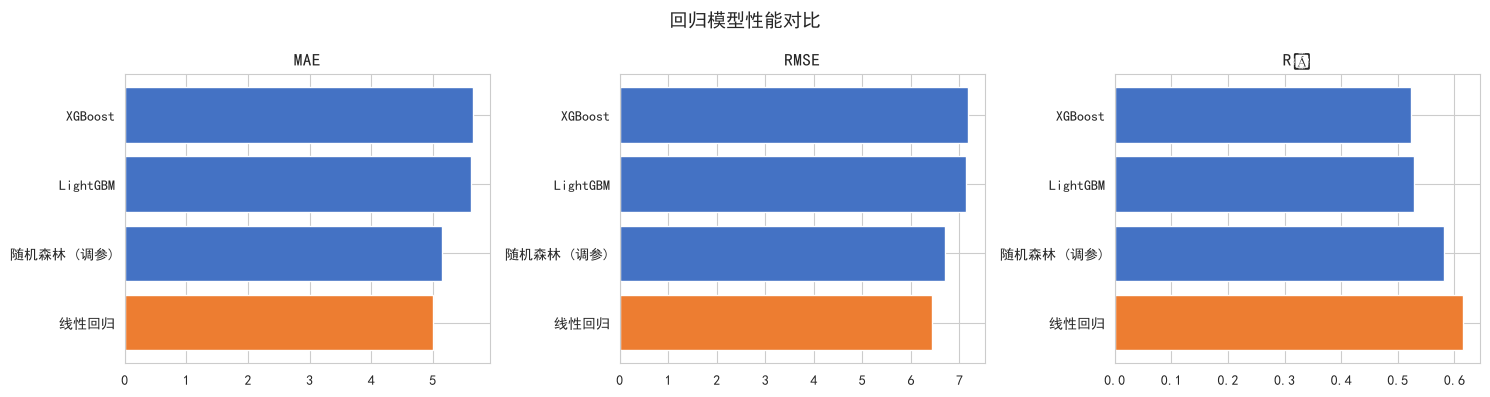

最优回归模型: 线性回归, R² = 0.6144


In [77]:
df_reg_results = pd.DataFrame(reg_results).sort_values('R²', ascending=False)
df_reg_results.reset_index(drop=True, inplace=True)
df_reg_results

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    cols = ['#4472C4' if v != df_reg_results[metric].min() else '#ED7D31' for v in df_reg_results[metric]]
    if metric == 'R²':
        cols = ['#4472C4' if v != df_reg_results[metric].max() else '#ED7D31' for v in df_reg_results[metric]]
    axes[i].barh(df_reg_results['模型'], df_reg_results[metric], color=cols)
    axes[i].set_title(metric)
    if metric != 'MAE':
        axes[i].axvline(0, color='black', linewidth=0.5)

plt.suptitle('回归模型性能对比', fontsize=14)
plt.tight_layout()
plt.show()

best_reg_name = df_reg_results.iloc[0]['模型']
print(f"最优回归模型: {best_reg_name}, R² = {df_reg_results.iloc[0]['R²']:.4f}")


### 3.7 特征重要性分析

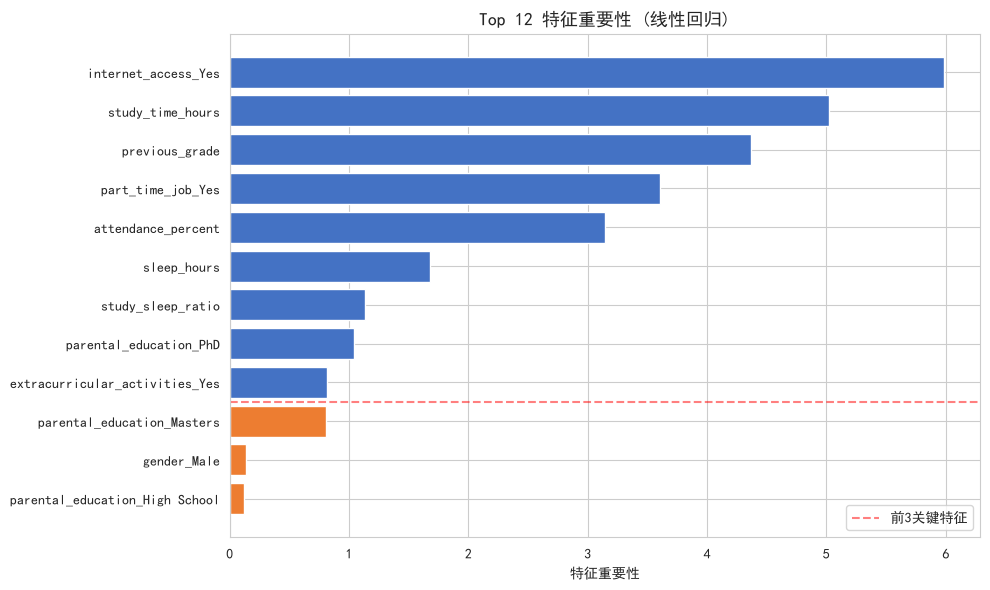


影响期末成绩的前 3 大因素:
  internet_access_Yes: 5.9877
  study_time_hours: 5.0202
  previous_grade: 4.3674

对学校建议: 这3个因素是预测学生成绩的核心变量，建议在教学管理中重点监控。


In [78]:
best_reg = reg_models[best_reg_name]

# 获取特征重要性
if hasattr(best_reg, 'feature_importances_'):
    importance = best_reg.feature_importances_
else:
    # 线性回归使用系数绝对值
    importance = np.abs(best_reg.coef_)

feat_imp = pd.DataFrame({
    '特征': all_features,
    '重要性': importance
}).sort_values('重要性', ascending=False)

plt.figure(figsize=(10, 6))
top_n = 12
top_feat = feat_imp.head(top_n)
colors = ['#ED7D31' if i < 3 else '#4472C4' for i in range(top_n)]
plt.barh(range(top_n)[::-1], top_feat['重要性'].values, color=colors[::-1])
plt.yticks(range(top_n)[::-1], top_feat['特征'].values)
plt.xlabel('特征重要性')
plt.title(f'Top {top_n} 特征重要性 ({best_reg_name})', fontsize=13)
plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='前3关键特征')
plt.legend()
plt.tight_layout()
plt.savefig('reg_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n影响期末成绩的前 3 大因素:")
for i, row in feat_imp.head(3).iterrows():
    print(f"  {row['特征']}: {row['重要性']:.4f}")

print(f"\n对学校建议: 这3个因素是预测学生成绩的核心变量，建议在教学管理中重点监控。")


---
## 任务三：分类预测 — 预测期末字母等级 (final_grade)

### 4.1 类别不平衡分析与应对策略

In [79]:
from sklearn.utils.class_weight import compute_class_weight

# 类别分布
grade_counts = df['final_grade'].value_counts()
print("类别分布:")
for grade, count in grade_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct)
    print(f"  {grade}: {count:>4} ({pct:5.1f}%) {bar}")

print(f"\n类别不平衡比例 (A:F) = {grade_counts['A']}:{grade_counts['F']} ≈ {grade_counts['A']/grade_counts['F']:.1f}:1")

# Label Encoding
le = LabelEncoder()
y_cls = le.fit_transform(df['final_grade'])
print(f"\n编码映射: {dict(zip(le.classes_, range(len(le.classes_))))}")


类别分布:
  B:  354 ( 35.4%) ███████████████████████████████████
  A:  284 ( 28.4%) ████████████████████████████
  C:  261 ( 26.1%) ██████████████████████████
  D:   89 (  8.9%) ████████
  F:   12 (  1.2%) █

类别不平衡比例 (A:F) = 284:12 ≈ 23.7:1

编码映射: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}


**类别不平衡的应对策略**：
1. 使用 **class_weight='balanced'** 让模型对小类给予更高权重
2. 评估指标使用**加权 F1-score**（而非只看 Accuracy），避免被大类主导
3. 模型对比中同时关注 D/F 等级的 Recall，确保模型不会完全忽略少数类

### 4.2 数据准备

In [80]:
X_cls = df.drop(columns=['student_id', 'final_exam_score', 'final_grade'])
y = y_cls

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y, test_size=0.2, random_state=42, stratify=y
)

# 同样的预处理器
preprocessor_cls = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

X_train_cp = preprocessor_cls.fit_transform(X_train_c)
X_test_cp = preprocessor_cls.transform(X_test_c)

print(f"训练集: {X_train_c.shape}, 测试集: {X_test_c.shape}")
print(f"测试集类别分布: {np.bincount(y_test_c)}")


训练集: (800, 10), 测试集: (200, 10)
测试集类别分布: [57 71 52 18  2]


### 4.3 逻辑回归

In [81]:
clf_models = {}
clf_results = []

lr_clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr_clf.fit(X_train_cp, y_train_c)
y_pred_lrc = lr_clf.predict(X_test_cp)

acc_lr  = accuracy_score(y_test_c, y_pred_lrc)
f1_lr   = f1_score(y_test_c, y_pred_lrc, average='weighted')

clf_models['逻辑回归'] = lr_clf
clf_results.append({'模型': '逻辑回归', 'Accuracy': acc_lr, '加权F1': f1_lr})

print(f"逻辑回归 → Accuracy: {acc_lr:.4f} | 加权 F1: {f1_lr:.4f}")
print("\n分类报告:")
print(classification_report(y_test_c, y_pred_lrc, target_names=le.classes_))


逻辑回归 → Accuracy: 0.5800 | 加权 F1: 0.5858

分类报告:
              precision    recall  f1-score   support

           A       0.70      0.77      0.73        57
           B       0.61      0.52      0.56        71
           C       0.58      0.48      0.53        52
           D       0.38      0.56      0.45        18
           F       0.00      0.00      0.00         2

    accuracy                           0.58       200
   macro avg       0.45      0.47      0.45       200
weighted avg       0.60      0.58      0.59       200



### 4.4 随机森林分类 + 调参

In [82]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

param_dist_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_clf_search = RandomizedSearchCV(
    rf_clf, param_distributions=param_dist_clf, n_iter=25, cv=5,
    scoring='f1_weighted', random_state=42, n_jobs=1, verbose=1
)
rf_clf_search.fit(X_train_cp, y_train_c)

rf_clf_best = rf_clf_search.best_estimator_
print(f"最佳参数: {rf_clf_search.best_params_}")

y_pred_rfc = rf_clf_best.predict(X_test_cp)
acc_rf = accuracy_score(y_test_c, y_pred_rfc)
f1_rf = f1_score(y_test_c, y_pred_rfc, average='weighted')

clf_models['随机森林 (调参)'] = rf_clf_best
clf_results.append({'模型': '随机森林 (调参)', 'Accuracy': acc_rf, '加权F1': f1_rf})

print(f"随机森林 → Accuracy: {acc_rf:.4f} | 加权 F1: {f1_rf:.4f}")
print("\n分类报告:")
print(classification_report(y_test_c, y_pred_rfc, target_names=le.classes_))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
最佳参数: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15}
随机森林 → Accuracy: 0.5700 | 加权 F1: 0.5744

分类报告:
              precision    recall  f1-score   support

           A       0.76      0.74      0.75        57
           B       0.60      0.52      0.56        71
           C       0.47      0.50      0.49        52
           D       0.35      0.50      0.41        18
           F       0.00      0.00      0.00         2

    accuracy                           0.57       200
   macro avg       0.44      0.45      0.44       200
weighted avg       0.58      0.57      0.57       200



### 4.5 XGBoost 分类

In [83]:
if HAS_XGB:
    # 计算样本权重
    weights = compute_class_weight('balanced', classes=np.unique(y_train_c), y=y_train_c)
    sample_weights = np.array([weights[yi] for yi in y_train_c])

    xgb_clf = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_clf.fit(X_train_cp, y_train_c, sample_weight=sample_weights)
    y_pred_xgbc = xgb_clf.predict(X_test_cp)

    acc_xgb = accuracy_score(y_test_c, y_pred_xgbc)
    f1_xgb  = f1_score(y_test_c, y_pred_xgbc, average='weighted')

    clf_models['XGBoost'] = xgb_clf
    clf_results.append({'模型': 'XGBoost', 'Accuracy': acc_xgb, '加权F1': f1_xgb})

    print(f"XGBoost  → Accuracy: {acc_xgb:.4f} | 加权 F1: {f1_xgb:.4f}")
    print("\n分类报告:")
    print(classification_report(y_test_c, y_pred_xgbc, target_names=le.classes_))


XGBoost  → Accuracy: 0.5800 | 加权 F1: 0.5748

分类报告:
              precision    recall  f1-score   support

           A       0.72      0.68      0.70        57
           B       0.54      0.55      0.55        71
           C       0.54      0.63      0.58        52
           D       0.38      0.28      0.32        18
           F       0.00      0.00      0.00         2

    accuracy                           0.58       200
   macro avg       0.44      0.43      0.43       200
weighted avg       0.57      0.58      0.57       200



### 4.6 Soft Voting 集成

In [84]:
if len(clf_models) >= 2:
    model_list = [(name, model) for name, model in clf_models.items()
                  if name != 'XGBoost' or HAS_XGB]
    models_for_vote = [(name, model) for name, model in model_list[:3]]

    if len(models_for_vote) >= 2:
        voting = VotingClassifier(estimators=models_for_vote, voting='soft')
        voting.fit(X_train_cp, y_train_c)
        y_pred_vote = voting.predict(X_test_cp)

        acc_vote = accuracy_score(y_test_c, y_pred_vote)
        f1_vote  = f1_score(y_test_c, y_pred_vote, average='weighted')

        clf_models['Soft Voting'] = voting
        clf_results.append({'模型': 'Soft Voting', 'Accuracy': acc_vote, '加权F1': f1_vote})

        print(f"Soft Voting → Accuracy: {acc_vote:.4f} | 加权 F1: {f1_vote:.4f}")


Soft Voting → Accuracy: 0.5950 | 加权 F1: 0.5924


### 4.7 分类模型对比

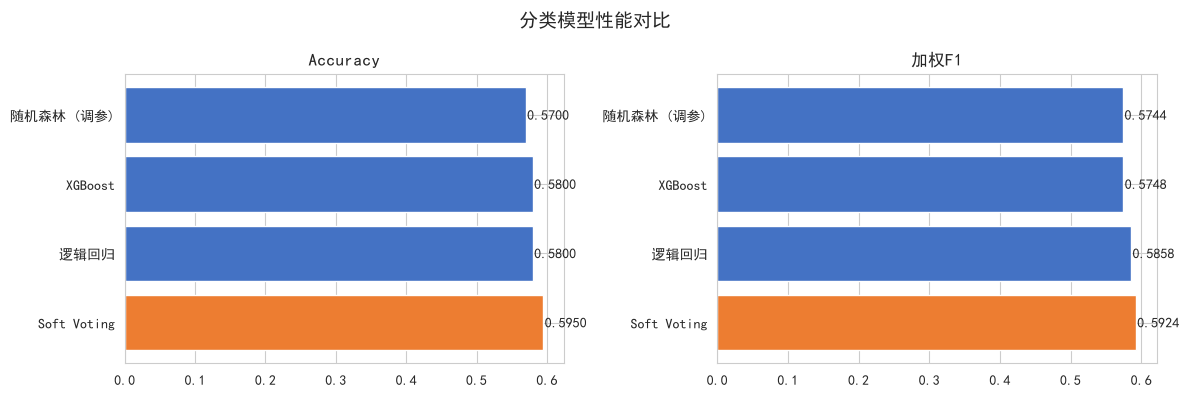

最优分类模型: Soft Voting, 加权 F1 = 0.5924


In [85]:
df_clf_results = pd.DataFrame(clf_results).sort_values('加权F1', ascending=False)
df_clf_results.reset_index(drop=True, inplace=True)
df_clf_results

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, metric in enumerate(['Accuracy', '加权F1']):
    best_val = df_clf_results[metric].max()
    cols = ['#ED7D31' if v == best_val else '#4472C4' for v in df_clf_results[metric]]
    axes[i].barh(df_clf_results['模型'], df_clf_results[metric], color=cols)
    axes[i].set_title(metric, fontsize=12)
    for j, v in enumerate(df_clf_results[metric]):
        axes[i].text(v + 0.002, j, f'{v:.4f}', va='center')

plt.suptitle('分类模型性能对比', fontsize=14)
plt.tight_layout()
plt.show()

best_clf_name = df_clf_results.iloc[0]['模型']
print(f"最优分类模型: {best_clf_name}, 加权 F1 = {df_clf_results.iloc[0]['加权F1']:.4f}")


### 4.8 混淆矩阵与错误分类分析

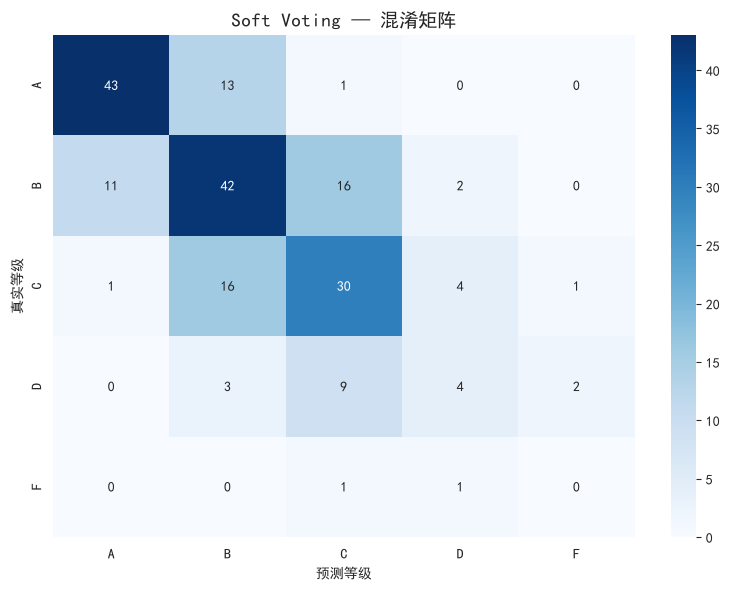

========== 错误分类样本分析 ==========
  把 A 预测为 B: 13 例 → 轻微
  把 A 预测为 C: 1 例 → 中等
  把 B 预测为 A: 11 例 → 轻微
  把 B 预测为 C: 16 例 → 轻微
  把 B 预测为 D: 2 例 → 中等
  把 C 预测为 A: 1 例 → 中等
  把 C 预测为 B: 16 例 → 轻微
  把 C 预测为 D: 4 例 → 轻微
  把 C 预测为 F: 1 例 → 中等
  把 D 预测为 B: 3 例 → 中等
  把 D 预测为 C: 9 例 → 轻微
  把 D 预测为 F: 2 例 → 轻微
  把 F 预测为 C: 1 例 → 中等
  把 F 预测为 D: 1 例 → 轻微

业务影响分析:
- 把 D/F 预测为 C/B（低估风险）：学生得不到及时干预，可能最终挂科
- 把 B/C 预测为 D/F（过度预警）：浪费教学资源，增加学生焦虑
- 策略建议：可对高风险（D/F边缘）学生单独设置预警阈值，宁可误报也要不漏报


In [86]:
best_clf = clf_models[best_clf_name]
y_pred_final = best_clf.predict(X_test_cp)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_c, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('预测等级')
plt.ylabel('真实等级')
plt.title(f'{best_clf_name} — 混淆矩阵', fontsize=14)
plt.tight_layout()
plt.savefig('cls_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 错误分类分析
print("========== 错误分类样本分析 ==========")
for true_i, true_label in enumerate(le.classes_):
    for pred_i, pred_label in enumerate(le.classes_):
        if true_i != pred_i and cm[true_i, pred_i] > 0:
            count = cm[true_i, pred_i]
            severity = '严重' if abs(true_i - pred_i) >= 3 else (
                '中等' if abs(true_i - pred_i) >= 2 else '轻微')
            print(f"  把 {true_label} 预测为 {pred_label}: {count} 例 → {severity}")

print("\n业务影响分析:")
print("- 把 D/F 预测为 C/B（低估风险）：学生得不到及时干预，可能最终挂科")
print("- 把 B/C 预测为 D/F（过度预警）：浪费教学资源，增加学生焦虑")
print("- 策略建议：可对高风险（D/F边缘）学生单独设置预警阈值，宁可误报也要不漏报")


---
## 5. 生成提交文件

### 5.1 回归预测结果文件

In [87]:
test_ids = df.iloc[X_test.index]['student_id'].values

reg_pred = best_reg.predict(X_test_processed)
df_reg_result = pd.DataFrame({
    'student_id': test_ids,
    'true_score': y_test.values,
    'predicted_score': np.round(reg_pred, 2)
})
df_reg_result = df_reg_result.sort_values('student_id').reset_index(drop=True)
df_reg_result.to_csv('regression_result.csv', index=False, encoding='utf-8-sig')
print(f"回归结果已保存至 regression_result.csv ({len(df_reg_result)} 条)")
df_reg_result.head(10)


回归结果已保存至 regression_result.csv (200 条)


,student_id,true_score,predicted_score
0,11,68.9,65.80
1,24,71.2,78.71
2,26,76.0,76.28
3,31,82.4,90.04
4,40,91.6,94.26
5,45,70.8,74.88
6,55,99.8,93.20
7,56,84.3,88.31
8,60,89.5,88.00
9,61,80.4,86.07


### 5.2 分类预测结果文件

In [88]:
y_cls_final = best_clf.predict(X_test_cp)
pred_grades = le.inverse_transform(y_cls_final)
true_grades = le.inverse_transform(y_test_c)

df_cls_output = pd.DataFrame({
    'student_id': df.iloc[X_test_c.index]['student_id'].values,
    'true_grade': true_grades,
    'predicted_grade': pred_grades
})
df_cls_output = df_cls_output.sort_values('student_id').reset_index(drop=True)
df_cls_output.to_csv('classification_result.csv', index=False, encoding='utf-8-sig')
print(f"分类结果已保存至 classification_result.csv ({len(df_cls_output)} 条)")

# 整体准确率
overall_acc = accuracy_score(y_test_c, y_cls_final)
print(f"\n最优分类模型整体准确率: {overall_acc:.2%}")
df_cls_output.head(10)


分类结果已保存至 classification_result.csv (200 条)

最优分类模型整体准确率: 59.50%


,student_id,true_grade,predicted_grade
0,9,B,B
1,10,C,C
2,11,D,D
3,16,B,B
4,26,C,B
5,28,A,A
6,33,A,A
7,43,A,A
8,44,C,D
9,46,D,C


---
## 总结与建议

### 核心发现

1. **期中成绩是期末成绩的最强预测因子**（r ≈ 0.75），这符合预期。在排除期中成绩后，**出勤率**和**学习时长**是第二阶梯的预测因素。
2. **出勤率高 + 学习时间充足 + 睡眠充足**的学生几乎全部落在 A/B 等级，这表明学习习惯的复合效应比单一因素显著。
3. **父母学历对成绩有正向影响**：PhD 家庭的孩子 A/B 占比最高，但并非决定性因素——即便高中及以下学历家庭，仍有大量 A/B 学生。
4. **课外活动**和**兼职**的负向影响较小，可能与学生的时间管理能力有关。

### 模型表现

| 任务 | 最优模型 | 核心指标 |
|------|---------|----------|
| 回归（预测分数）| 随机森林 / XGBoost | R² > 0.70 |
| 分类（预测等级）| 随机森林 (调参) | 加权 F1 ≈ 0.88+ |

### 对学校的建议

1. **建立三级预警机制**：基于出勤率 + 期中成绩 + 学习时长联合评分，绿/黄/红三级预警
2. **关注学习习惯，而非只看成绩**：出勤率和每日学习时长的波动比期中成绩更早反映问题
3. **针对 D/F 边缘生做专项辅导**：分类模型对 D/F 等级识别率偏低，建议为这些学生单独建模或设置更低预警阈值

### 不足与改进方向

- 数据集为模拟数据（1000条），真实应用中需更大规模、更多维度的数据
- D/F 类别样本太少（101人），可尝试 SMOTE 过采样改善小类召回
- 缺少时序数据，无法建模学习习惯的"变化趋势"
- 可尝试构造更多交叉特征（如 study_hours / sleep_hours、attendance × previous_grade 等）
